# Spotify Top-10 Classifier Comparison — Audio Features Split

This notebook demonstrates the full workflow for predicting whether a song will reach the Top-10:
1. Load and preprocess the dataset.
2. Configure shared hyperparameters and build four classifier baselines.
3. Train each model on the same splits and evaluate metrics.
4. Visualize metric comparisons and inspect confusion matrices.

This variant evaluates models using only the raw Spotify audio feature columns (danceability, energy, loudness, etc.).


In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from ml.data import (
    AUDIO_FEATURES,
    RANK_COLUMN,
    create_classification_splits,
    load_classification_dataframe,
)
from ml.evaluation import (
    evaluate_classifier,
    evaluate_classifier_splits,
    build_confusion_matrix,
    log_training_step,
)
from ml.models import (
    build_logistic_regression,
    build_neural_network,
    build_random_forest,
    build_svm,
)
from ml.train import (
    plot_training_history,
    train_models,
    train_random_forest_incremental,
)
from tqdm.auto import tqdm

/Users/hallaei/miniconda3/envs/aml_cwl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)


In [3]:
DATA_PATH = Path("data/datasets/Spotify_Dataset_V3.csv")
TOP_K = 20 # Classification threshold
HOLDOUT_FRACTION = 0.4 # 40% of data held out for validation and testing, rest to training
DEV_SHARE = 0.5 # Of the HOLDOUT_FRACTION% holdoput, 0.5 (50%) to dev, rest to test
RANDOM_STATE = 42 # Random seed for reproducibility
METRICS_PATH = Path("data/results/audio_classifier_metrics.csv")
TRAINING_LOG_PATH = Path("data/results/audio_training_steps.csv")
TRAINING_HISTORY_DIR = Path("data/results/audio_training_histories")
TRAINING_PLOT_DIR = Path("data/results/audio_training_plots")
MAX_EPOCS = 15
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 1e-4

FEATURE_SET_NAME = "Audio Features"
feature_cols = AUDIO_FEATURES

## Load and prepare the dataset

In [4]:
classification_df, target_col = load_classification_dataframe(
    DATA_PATH, feature_cols, RANK_COLUMN, TOP_K, FEATURE_SET_NAME
)
print(
    f"Loaded {len(classification_df)} songs with Top-{TOP_K} label; "
    f"positive rate: {classification_df[target_col].mean():.2%}"
)
classification_df.head()

2025-11-20 07:53:05,220 [INFO] Loading dataset from data/datasets/Spotify_Dataset_V3.csv
2025-11-20 07:53:06,062 [INFO] Prepared dataframe with 651936 songs (positive rate 9.69%).


Engineering Audio Features...
Loaded 651936 songs with Top-20 label; positive rate: 9.69%


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Rank,id,is_top_20
0,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,1,3qQbCzHBycnDpGskqOWY0E,1
1,0.668,0.758,-5176.0,0.033,0.483,0.000,0.834,1,3qQbCzHBycnDpGskqOWY0E,1
2,0.652,0.800,-4019.0,0.061,0.143,0.629,0.234,2,7ro0hRteUMfnOioTFI5TG1,1
3,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,3,2UW7JaomAMuX9pZrjVpHAU,1
4,0.812,0.479,-5678.0,0.333,0.213,0.000,0.559,3,2UW7JaomAMuX9pZrjVpHAU,1


In [5]:
train_df, dev_df, test_df = create_classification_splits(
    classification_df,
    target_col,
    HOLDOUT_FRACTION,
    DEV_SHARE,
    RANDOM_STATE,
)
print(
    f"Split sizes -> Train: {len(train_df)}, Dev: {len(dev_df)}, Test: {len(test_df)}"
)

train_X, train_y = (
    train_df[feature_cols], train_df[target_col]
)
dev_X, dev_y = (
    dev_df[feature_cols], dev_df[target_col]
)
test_X, test_y = (
    test_df[feature_cols], test_df[target_col]
)

2025-11-20 07:53:06,083 [INFO] Creating splits with holdout_fraction=0.40 and dev_share=0.50
2025-11-20 07:53:06,184 [INFO] Split sizes -> train=402823, dev=124540, test=124573
2025-11-20 07:53:06,184 [INFO] Train split positive rate: 9.38%
2025-11-20 07:53:06,185 [INFO] Dev split positive rate: 10.09%
2025-11-20 07:53:06,185 [INFO] Test split positive rate: 10.30%


Split sizes -> Train: 402823, Dev: 124540, Test: 124573


## Build the classifier baselines

In [6]:
models = {
    "Logistic Regression": build_logistic_regression(RANDOM_STATE),
    "Neural Network": build_neural_network(
        RANDOM_STATE
    ),
    "Random Forest": build_random_forest(
        RANDOM_STATE, n_estimators=20, max_depth=None
    ),
    "SVM (Approx RBF)": build_svm(
        RANDOM_STATE,
        kernel="rbf",
        gamma="scale",
        approximate=True,
        n_components=100,
        sgd_alpha=5e-5,
        sgd_max_iter=100,
    ),
}
models


{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('classifier',
                  SGDClassifier(alpha=0.01, eta0=0.01, l1_ratio=0.3,
                                learning_rate='constant', loss='log_loss',
                                max_iter=10, penalty='elasticnet',
                                random_state=42, tol=None, warm_start=True))]),
 'Neural Network': Pipeline(steps=[('scaler', StandardScaler()),
                 ('classifier',
                  MLPClassifier(activation='tanh', hidden_layer_sizes=(32,),
                                learning_rate='adaptive',
                                learning_rate_init=0.01, max_iter=500,
                                random_state=42, solver='sgd'))]),
 'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=20, n_jobs=-1,
                        random_state=42, warm_start=True),
 'SVM (Approx RBF)': Pipeline(steps=[('scaler', StandardScaler()),
                 

## Train and evaluate

In [7]:

# Prepare splits
train_split = (train_X, train_y)
dev_split = (dev_X, dev_y)
test_split = (test_X, test_y)
dataset_splits = {
    "Train": train_split,
    "Dev": dev_split,
    "Test": test_split,
}

classes = sorted(train_df[target_col].unique())
incremental_models = {
    name: model for name, model in models.items() if name != "Random Forest"
}

training_histories = {}
training_metrics = {}

if incremental_models:
    trained_models, incremental_histories, incremental_metrics = train_models(
        incremental_models,
        train_split,
        dev_split,
        epochs=MAX_EPOCS,
        classes=classes,
        history_dir=TRAINING_HISTORY_DIR,
        plot_dir=TRAINING_PLOT_DIR,
        plot_title_template=f"{FEATURE_SET_NAME} - {{name}}",
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        return_metrics=True,
    )
    models.update(trained_models)
    training_histories.update(incremental_histories)
    training_metrics.update(incremental_metrics)

random_forest = models["Random Forest"]
random_forest, rf_history = train_random_forest_incremental(
    random_forest,
    train_split,
    dev_split,
    epochs=MAX_EPOCS,
    history_path=TRAINING_HISTORY_DIR / "random_forest_history.csv",
    plot_path=TRAINING_PLOT_DIR / "random_forest_training.png",
    plot_title=f"{FEATURE_SET_NAME} - Random Forest",
    classes=classes,
)
models["Random Forest"] = random_forest
training_histories["Random Forest"] = rf_history
training_metrics["Random Forest"] = evaluate_classifier_splits(
    random_forest,
    {"train": train_split, "dev": dev_split},
)

metrics_records = []
eval_bar = tqdm(total=len(models) * len(dataset_splits), desc="Evaluating splits")
for name, model in models.items():
    split_metrics = evaluate_classifier_splits(
        model,
        {"train": train_split, "dev": dev_split, "test": test_split},
    )
    for split_label, (X_split, y_split) in dataset_splits.items():
        split_key = split_label.lower()
        metrics = {
            key.replace(f"{split_key}_", ""): value
            for key, value in split_metrics.items()
            if key.startswith(split_key)
        }
        metrics_with_meta = {**metrics, "model": name, "split": split_label}
        metrics_records.append(metrics_with_meta)

        training_record = {
            "timestamp": pd.Timestamp.utcnow().isoformat(),
            "model": name,
            "split": split_label,
            "feature_set": FEATURE_SET_NAME,
            "feature_columns": ",".join(map(str, feature_cols)),
            "feature_count": len(feature_cols),
            "random_state": RANDOM_STATE,
            "holdout_fraction": HOLDOUT_FRACTION,
            "dev_share": DEV_SHARE,
            "top_k": TOP_K,
            "rows": len(X_split),
        }
        training_record.update(metrics)
        log_training_step(TRAINING_LOG_PATH, training_record)
        eval_bar.update(1)

eval_bar.close()

metrics_df = (
    pd.DataFrame(metrics_records)
    .sort_values(["split", "model"])
    .reset_index(drop=True)
)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(METRICS_PATH, index=False)
logging.info("Saved metrics to %s", METRICS_PATH)
metrics_df

2025-11-20 07:53:06,206 [INFO] Training Logistic Regression for 15 epochs
2025-11-20 07:53:06,521 [INFO] Epoch 1/15 - loss: 1.2034 - val_loss: 0.3262 - accuracy: 0.5000 - val_accuracy: 0.8991 - auc: 0.5341 - val_auc: 0.5697
2025-11-20 07:53:06,816 [INFO] Epoch 2/15 - loss: 1.2034 - val_loss: 0.3262 - accuracy: 0.5000 - val_accuracy: 0.8991 - auc: 0.5341 - val_auc: 0.5697
2025-11-20 07:53:07,159 [INFO] Epoch 3/15 - loss: 1.2034 - val_loss: 0.3262 - accuracy: 0.5000 - val_accuracy: 0.8991 - auc: 0.5341 - val_auc: 0.5697
2025-11-20 07:53:07,163 [INFO] Early stopping triggered after 3 epochs (no val_loss improvement for 2 epochs).
2025-11-20 07:53:07,169 [INFO] Saved training history to data/results/audio_training_histories/logistic-regression_history.csv
2025-11-20 07:53:07,351 [INFO] Saved training plot to data/results/audio_training_plots/logistic-regression_training.png
2025-11-20 07:53:07,601 [INFO] Training Neural Network for 15 epochs
2025-11-20 07:53:09,393 [INFO] Epoch 1/15 - loss

,accuracy,precision,recall,f1,auc,top10_hit_rate,model,split
0,0.899101,0.000000,0.000000,0.000000,0.569749,0.000000,Logistic Regression,Dev
1,0.899101,0.000000,0.000000,0.000000,0.535387,0.000000,Neural Network,Dev
2,0.856568,0.133932,0.077113,0.097874,0.534813,0.077113,Random Forest,Dev
3,0.665666,0.099934,0.288954,0.148507,0.518582,0.288954,SVM (Approx RBF),Dev
4,0.897040,0.000000,0.000000,0.000000,0.512885,0.000000,Logistic Regression,Test
5,0.897040,0.000000,0.000000,0.000000,0.485608,0.000000,Neural Network,Test
6,0.871754,0.244981,0.117964,0.159246,0.577870,0.117964,Random Forest,Test
7,0.663980,0.087424,0.239825,0.128137,0.470502,0.239825,SVM (Approx RBF),Test
8,0.906195,0.000000,0.000000,0.000000,0.534053,0.000000,Logistic Regression,Train
9,0.906195,0.000000,0.000000,0.000000,0.610935,0.000000,Neural Network,Train


## Training curves — incremental models
Visualize per-epoch loss/accuracy for models trained with partial-fit style updates.

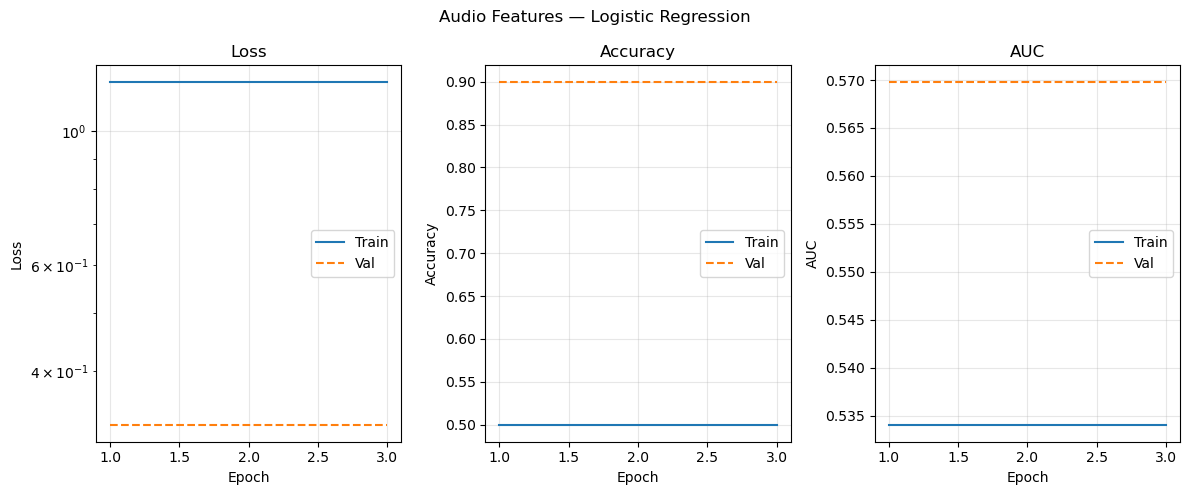

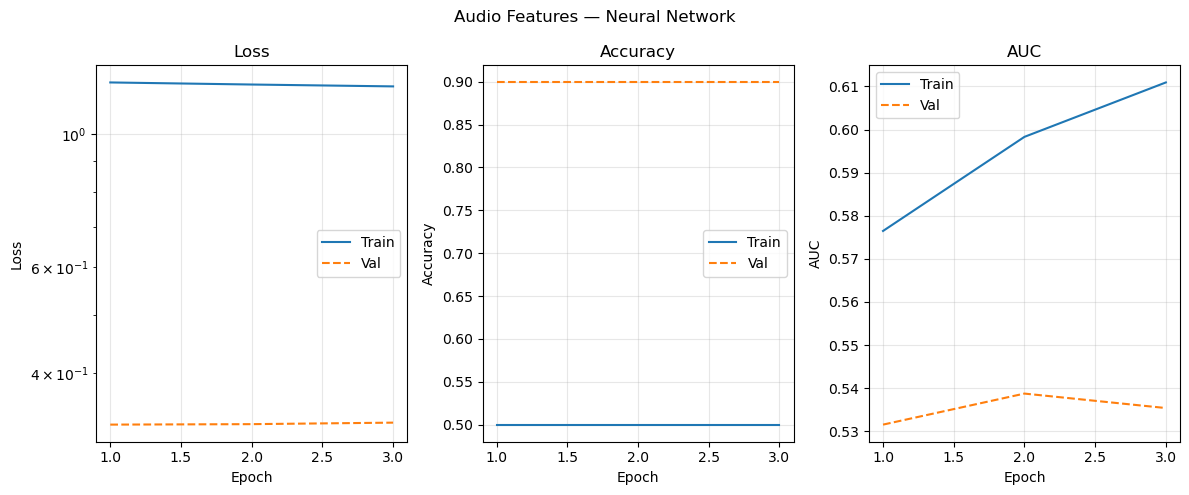

In [8]:
incremental_histories = {
    name: history for name, history in training_histories.items()
    if name != "Random Forest"
    if name != "SVM (Approx RBF)"
}

if incremental_histories:
    for name, history_df in incremental_histories.items():
        fig, axes = plt.subplots(1, 3, figsize=(12, 5))
        
        # Loss plot
        axes[0].plot(history_df["epoch"], history_df["loss"], label="Train")
        axes[0].plot(history_df["epoch"], history_df["val_loss"], linestyle="--", label="Val")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_yscale("log")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Accuracy plot
        axes[1].plot(history_df["epoch"], history_df["accuracy"], label="Train")
        axes[1].plot(history_df["epoch"], history_df["val_accuracy"], linestyle="--", label="Val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # AUC plot
        axes[2].plot(history_df["epoch"], history_df["auc"], label="Train")
        axes[2].plot(history_df["epoch"], history_df["val_auc"], linestyle="--", label="Val")
        axes[2].set_title("AUC")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("AUC")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        fig.suptitle(f"{FEATURE_SET_NAME} — {name}")
        plt.tight_layout()
        plt.show()
        plt.close(fig)
else:
    print("No incremental model histories available.")


## Random Forest growth curve
Track how performance evolves as additional trees are added with warm-start training.

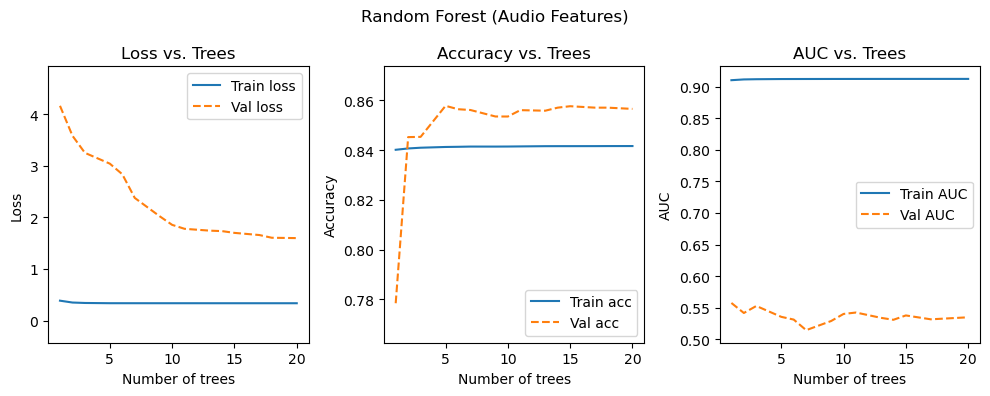

In [9]:
rf_history = training_histories.get("Random Forest")
if rf_history is not None:
    trees = rf_history.get("n_estimators")
    if trees is None or trees.isnull().all():
        trees = rf_history["epoch"]

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].plot(trees, rf_history["loss"], label="Train loss")
    axes[0].plot(trees, rf_history["val_loss"], linestyle="--", label="Val loss")
    axes[0].set_title("Loss vs. Trees")
    axes[0].set_xlabel("Number of trees")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(trees, rf_history["accuracy"], label="Train acc")
    axes[1].plot(trees, rf_history["val_accuracy"], linestyle="--", label="Val acc")
    axes[1].set_title("Accuracy vs. Trees")
    axes[1].set_xlabel("Number of trees")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    axes[2].plot(trees, rf_history["auc"], label="Train AUC")
    axes[2].plot(trees, rf_history["val_auc"], linestyle="--", label="Val AUC")
    axes[2].set_title("AUC vs. Trees")
    axes[2].set_xlabel("Number of trees")
    axes[2].set_ylabel("AUC")
    axes[2].legend()

    def _tighten_axis(ax, series):
        series = series.dropna()
        if series.empty:
            return
        y_min = series.min()
        y_max = series.max()
        if y_min == y_max:
            margin = max(0.001, abs(y_min) * 0.05)
        else:
            margin = (y_max - y_min) * 0.2
        ax.set_ylim(y_min - margin, y_max + margin)

    _tighten_axis(axes[0], pd.concat([rf_history["loss"], rf_history["val_loss"]]))
    _tighten_axis(axes[1], pd.concat([rf_history["accuracy"], rf_history["val_accuracy"]]))

    fig.suptitle(f"Random Forest ({FEATURE_SET_NAME})")
    fig.tight_layout()
    # display(fig)
else:
    print("Random Forest history unavailable.")


## Visualize performance on the test split

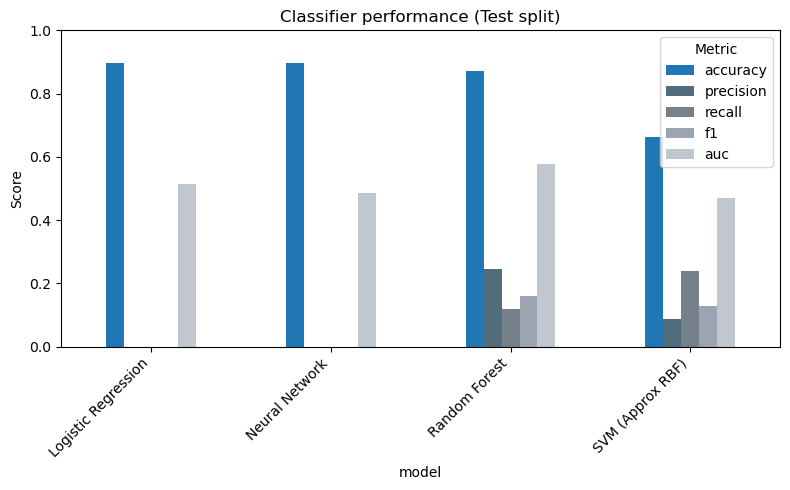

In [ ]:
test_metrics = metrics_df[metrics_df["split"] == "Test"].set_index("model")
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc"]
color_palette = [
    "#1f77b4",  # blue
    "#4f6d7a",  # blue-gray
    "#75808a",  # medium gray-blue
    "#9aa5b1",  # soft gray
    "#c0c7cf",  # light gray
]
ax = test_metrics[metrics_to_plot].plot(
    kind="bar",
    color=color_palette,
    figsize=(8, 5)
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Classifier performance (Test split)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="Metric", loc="best")
plt.savefig("report/figures/audio_classifier_performance.png")
plt.tight_layout()


## Confusion matrices

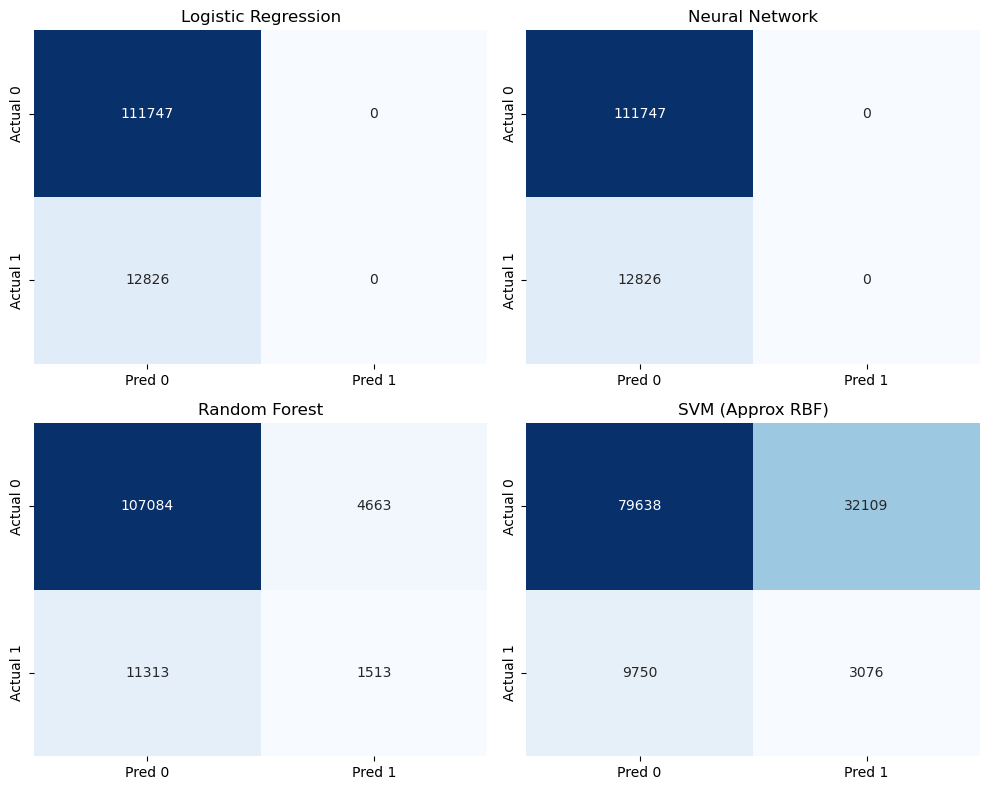

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    cm = build_confusion_matrix(
        model, dataset_splits["Test"][0], dataset_splits["Test"][1]
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
    )
    ax.set_title(name)

for ax in axes[len(models) :]:
    ax.axis("off")

plt.tight_layout()

## Inspect Specific Song IDs
Use this cell to enter Spotify song IDs and compare the model's prediction with the actual Top-10 label.


In [12]:
ids_to_inspect = [
    "3qQbCzHBycnDpGskqOWY0E",
]

model_name = "Random Forest"

if not ids_to_inspect:
    print("Add at least one song id to `ids_to_inspect` to inspect predictions.")
elif model_name not in models:
    raise ValueError(f"Unknown model {model_name!r}. Available models: {list(models)}")
else:
    inspection_rows = []
    for song_id in ids_to_inspect:
        song_rows = classification_df[classification_df["id"] == song_id]
        if song_rows.empty:
            inspection_rows.append(
                {
                    "song_id": song_id,
                    "predicted_top10": None,
                    "actual_top10": None,
                    "actual_rank": None,
                    "note": "ID not found in dataset",
                }
            )
            continue
        row = song_rows.sort_values(RANK_COLUMN).iloc[0]
        features = row[feature_cols].to_frame().T
        prediction = bool(models[model_name].predict(features)[0])
        actual_label = bool(row[target_col])
        inspection_rows.append(
            {
                "song_id": song_id,
                "predicted_top10": prediction,
                "actual_top10": actual_label,
                "actual_rank": row[RANK_COLUMN],
            }
        )
    pd.DataFrame(inspection_rows)
